/////////////////////////////////////////////////////////////////////////////////////////////////


/tmp/ipykernel_1819/1815948243.py:231: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_numeric = df_subjects.replace(status_map).infer_objects(copy=False)


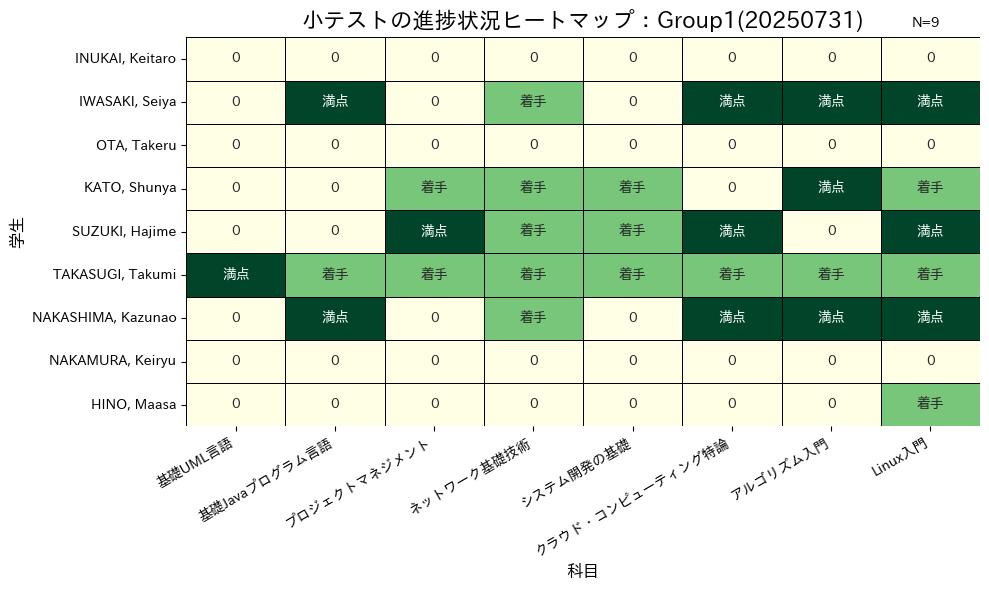

/////////////////////////////////////////////////////////////////////////////////////////////////


/tmp/ipykernel_1819/1815948243.py:231: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_numeric = df_subjects.replace(status_map).infer_objects(copy=False)


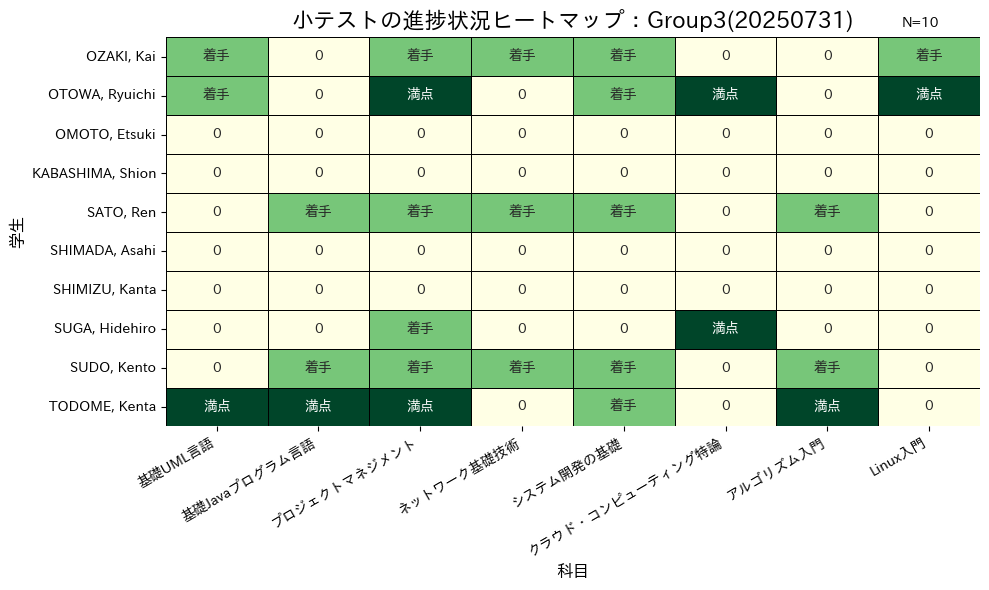

/////////////////////////////////////////////////////////////////////////////////////////////////


/tmp/ipykernel_1819/1815948243.py:231: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_numeric = df_subjects.replace(status_map).infer_objects(copy=False)


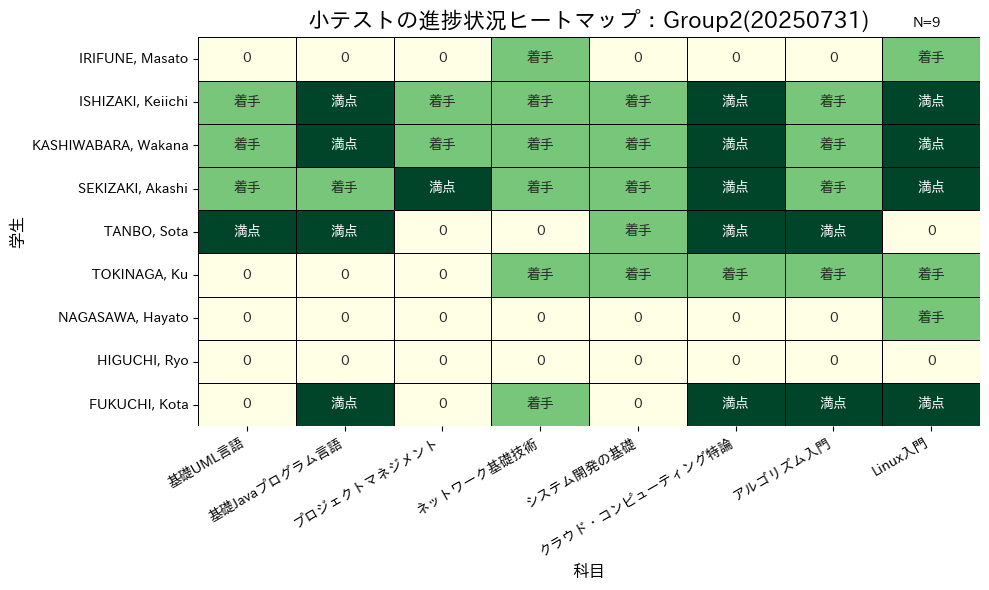

In [23]:
# 誰がどの科目を着手しているかを見るためのプログラム
import pandas as pd
import os
import datetime
import matplotlib.pyplot as plt
import japanize_matplotlib
from zoneinfo import ZoneInfo  # Python 3.9以上
from pathlib import Path
import seaborn as sns


# 定数として定義
# now = '20250424'
# now = '20250501'
# now = '20250508'
# now = '20250515'
# now = '20250522'
# now = '20250529'
# now = '20250605'
# now = '20250612'
# now = '20250619'
# now = '20250626'
# now = '20250703'
# now = '20250710'
# now = '20250717'
# now = '20250724'
now = '20250731'

folder_path = '/home/jovyan/work/shared_downloads/MiniTest/' + now
# folder_path = '/home/jovyan/work/shared_downloads/MiniTest/20250710'
OUTPUT_DIR = "/home/jovyan/work/graph_image"
GROUP_NAME = "none"
TOTAL_STUDENTS = 0

subjectNameList = [
    'プロジェクトマネジメント',
    '基礎UML言語',
    'Linux入門',
    'アルゴリズム入門',
    '基礎Javaプログラム言語',
    'クラウド・コンピューティング特論',
    'ネットワーク基礎技術',
    'システム開発の基礎'        
    ]

# CSVファイルの取得（フォルダの中身のcsvファイルの名前を配列で保存）
csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

# 各CSVファイルに対して処理
for csv_file in csv_files:
    CSV_PATH = os.path.join(folder_path, csv_file)
    try:
        # 元のCSVファイルを読み込む
        df = pd.read_csv(CSV_PATH)
        
        #残したい行を指定（グループの参加者を絞る）
        #自律性・有能感・関連性を支援したグループ
        rows_to_keep_group1 = [
            # "g2125004@fun.ac.jp",
            "g2125007@fun.ac.jp",
            "g2125010@fun.ac.jp",
            "g2125013@fun.ac.jp",
            "g2125023@fun.ac.jp",
            "g2125040@fun.ac.jp",
            "g2125044@fun.ac.jp",
            "g2125057@fun.ac.jp",
            "g2125059@fun.ac.jp",
            "g2125069@fun.ac.jp"
        ]
        
        #何も支援してないグループ
        rows_to_keep_group2 = [
            "g2124004@fun.ac.jp",
            "g2125002@fun.ac.jp",
            "g2125022@fun.ac.jp",
            "g2125042@fun.ac.jp",
            "g2125051@fun.ac.jp",
            "g2125054@fun.ac.jp",
            "g2125056@fun.ac.jp",
            "g2125068@fun.ac.jp",
            "g2125071@fun.ac.jp"
        ]
        
        #自律性だけ支援したグループ
        rows_to_keep_group3 = [
            "g2125018@fun.ac.jp",
            "g2125020@fun.ac.jp",
            "g2125021@fun.ac.jp",
            "g2125025@fun.ac.jp",
            "g2125035@fun.ac.jp",
            "g2125037@fun.ac.jp",
            "g2125038@fun.ac.jp",
            "g2125039@fun.ac.jp",
            "g2125041@fun.ac.jp",
            "g2125055@fun.ac.jp"
        ]
        
        
        #keitest4: 自律性・有能感・関連性を支援したグループ1
        #keilabtest5: 何も支援してないグループ2
        #keilabtest7: 自律性だけ支援したグループ3
        
        
        # CSV_PATHに"keitest4"が含まれている場合
        if "keitest4" in CSV_PATH:
            # 'メールアドレス'列に基づいてフィルタリング（rows_to_keep_group1を使用）
            df_filtered = df[df['メールアドレス'].isin(rows_to_keep_group1)]
            GROUP_NAME = "Group1"
            TOTAL_STUDENTS = 9
        elif "keilabtest5" in CSV_PATH:
            # 'メールアドレス'列に基づいてフィルタリング（rows_to_keep_group2を使用）
            df_filtered = df[df['メールアドレス'].isin(rows_to_keep_group2)]
            GROUP_NAME = "Group2"
            TOTAL_STUDENTS = 9
        elif "keilabtest7" in CSV_PATH:
            # 'メールアドレス'列に基づいてフィルタリング（rows_to_keep_group2を使用）
            df_filtered = df[df['メールアドレス'].isin(rows_to_keep_group3)]
            GROUP_NAME = "Group3"
            TOTAL_STUDENTS = 10
        else :
            # CSV_PATHがおかしい場合はエラーメッセージを表示して強制終了
            print("エラー: CSV_PATHがおかしいです。'keitest4'が含まれていません。")
            exit()  # 強制終了
        
        # 結果を確認
        # print(df_filtered)
        
        
        # 残したい列だけを指定
        columns_to_keep = [
            "名",
            "姓",
            "メールアドレス",
            "SCORMパッケージ:確認テスト（プロジェクトマネジメント） (実データ)",
            "SCORMパッケージ:確認テスト（基礎UML言語) (実データ)",
            "SCORMパッケージ:確認テスト（Linux入門） (実データ)",
            "SCORMパッケージ:確認テスト（アルゴリズム入門） (実データ)",
            "SCORMパッケージ:確認テスト（基礎Javaプログラム言語） (実データ)",
            "SCORMパッケージ:確認テスト（クラウド・コンピューティング特論） (実データ)",
            "小テスト:確認テスト（ネットワーク基礎技術） (実データ)",
            "小テスト:確認テスト（システム開発の基礎） (実データ)"
        ]
        
        # 列を抽出して新しいDataFrameを作成
        df_filtered = df_filtered[columns_to_keep]
        
        # #成形済みCSVとして出力
        # df_filtered.to_csv("./data/output_" + GROUP_NAME + ".csv", index=False, encoding="utf-8-sig")
        os.makedirs('./data/' + now, exist_ok=True)        
        df_filtered.to_csv("./data/" + now + "/output_" + GROUP_NAME + "_" + now + ".csv", index=False, encoding="utf-8-sig")
        # print(df_filtered)
        # print("///////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////")
        
        
        
        
        
        #データをさらに整理する
        # 点数を「未着手」「着手」「満点」に分類する関数
        def classify_score(value):
            if value == '-' or pd.isna(value):
                return '0'
            try:
                score = float(value)
                if score == 100.0:
                    return '満点'
                else:
                    return '着手'
            except ValueError:
                return '0'
        





        
        # 各列ごとに分類を行う
        # - -> 0
        # 1 ~ 99 -> 着手
        # 100 ->満点
        # 上記のようにデータを変換し、DataFrame型をオブジェクト型配列に変更して
        # subjectData["プロジェクトマネジメント"] = ['0', '0', '0', '0', '0', '満点', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '着手', '0', '着手', '0']
        # 上のようなオブジェクト配列を科目分作成する

        # subjectData = {}
        for column in df_filtered.columns:
            # 含まれているものを探す（部分一致）
            matched_subject = next(
                (name for name in subjectNameList if name in column or column in name),
                None
            )
            if matched_subject is None:
                # 一致しなければスキップするか、別途ログを出す
                print(f"Warning: '{column}' に対応するsubjectNameが見つかりません")
                continue
        
            # キーは matched_subject にして、値は classify_score を適用した結果リスト
            df_filtered[column] = df_filtered[column].apply(classify_score)

        os.makedirs('./data/' + now, exist_ok=True)
        df_filtered.to_csv("./data/" + now + "/output_" + GROUP_NAME + "_" + now + "_dump" + ".csv", index=False, encoding="utf-8-sig")
        print("/////////////////////////////////////////////////////////////////////////////////////////////////")

        
        
        
        # --- 1. データの前処理 ---
        # グラフの行ラベルとして使うため、姓と名を結合して'氏名'列を作成
        df_filtered['氏名'] = df_filtered['姓'].str.replace(r'\d+\s*', '', regex=True) + ', ' + df_filtered['名']
        # df_filtered = df_filtered.set_index('氏名') # '氏名'を行のインデックスに設定
        
        # グラフ化に必要な科目データのみを抽出
        subject_columns = [col for col in df_filtered.columns if 'SCORM' in col or '小テスト' in col]
        df_subjects = df_filtered[subject_columns]
        
        # 科目名を短縮して見やすくする
        df_subjects.columns = [
            'プロジェクトマネジメント', '基礎UML言語', 'Linux入門', 'アルゴリズム入門',
            '基礎Javaプログラム言語', 'クラウド・コンピューティング特論', 'ネットワーク基礎技術', 'システム開発の基礎'
        ]

        # 列名（科目名）を辞書順でソートする
        # df_subjects = df_subjects.sort_index(axis=1)
        df_subjects = df_subjects.sort_index(axis=1, ascending=False)

        
        # ヒートマップの色付けのために、ステータスを数値に変換する
        status_map = {'0': 0, '着手': 1, '満点': 2}
        # df_numeric = df_subjects.replace(status_map)
        df_numeric = df_subjects.replace(status_map).infer_objects(copy=False)
        
        
        # --- 2. ヒートマップの描画 ---
        plt.figure(figsize=(10, 6)) # グラフのサイズを調整
        
        # seabornのheatmap関数でグラフを作成
        sns.heatmap(
            df_numeric, # 色付けに使う数値データ
            annot=df_subjects,  # グラフ上に表示するテキスト（元のステータス）
            fmt='s', # annotに表示するテキストのフォーマット（文字列）
            cmap='YlGn', # 色のテーマ（Yellow to Green）
            linewidths=.5, # セル間の線の太さ
            linecolor='black', # セル間の線の色
            cbar=False, # カラーバーは非表示にする
            yticklabels=df_filtered['氏名'],
            vmin=0,  # カラーマップの最小値を0に固定
            vmax=2   # カラーマップの最大値を2に固定
        )
        
        # グラフの上に「N=●●」を表示（例えば右上）
        plt.text(
            0.95, 1.02, f'N={TOTAL_STUDENTS}',
            transform=plt.gca().transAxes,  # ax.transAxes を plt.gca().transAxes に変更
            ha='right', va='bottom',
            fontsize=10, fontweight='bold'
        )

            
        # グラフのタイトルとラベルの設定
        plt.title('小テストの進捗状況ヒートマップ：' + GROUP_NAME + '(' + now + ')', fontsize=16)
        plt.xlabel('科目', fontsize=12)
        plt.ylabel('学生', fontsize=12)
        plt.xticks(rotation=30, ha='right') # x軸のラベルを斜めにして見やすくする
        plt.yticks(rotation=0)
        
        # レイアウトを自動調整
        plt.tight_layout()

        plt.savefig("./data/" + now + "/heatmap_" + GROUP_NAME + "_" + now + ".png", dpi=300, bbox_inches='tight')
        
        # グラフを表示
        plt.show()

    except Exception as e:
        print(f'{csv_file} の処理中にエラーが発生しました: {e}')